# Phase 2–3: Fiona's Tickets

**Focus:**
- Completion Rate KPI
- Error Rate KPI  
- Hypothesis Test 3

## 1. Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest
import os

## 2. Load Data

In [21]:
demo_clean = pd.read_csv('demo_clean.csv')
df_web = pd.read_csv('web_combined.csv')
df_web['date_time'] = pd.to_datetime(df_web['date_time'])
exp = pd.read_csv('experiment.csv')
# Fixing nan values before data
exp = exp.dropna(subset=['Variation'])
df_web.head(5)

,client_id,visitor_id,visit_id,process_step,date_time
0,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
1,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
2,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
3,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
4,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09


In [22]:
demo_clean.head(4)

,client_id,client_tenure_years,client_tenure_months,client_age,gender,num_accts,balance,calls_last_6_months,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0


In [23]:
exp.head(4)

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test


In [24]:
df_web['client_id']

0             169
1             169
2             169
3             169
4             169
           ...   
744636    9999875
744637    9999875
744638    9999875
744639    9999875
744640    9999875
Name: client_id, Length: 744641, dtype: int64

---
## 3. Completion Rate KPI

In [25]:
# Get the last step in each visit
last_step = (df_web.sort_values('date_time').groupby('visit_id', as_index=False).agg(client_id=('client_id', 'first'),last_step=('process_step', 'last')))
last_step = last_step.merge(exp, on='client_id', how='inner')
last_step['completed'] = (last_step['last_step'] == 'confirm').astype(int)

In [26]:
last_step

,visit_id,client_id,last_step,Variation,completed
0,100012776_37918976071_457913,3561384,confirm,Test,1
1,100019538_17884295066_43909,7338123,confirm,Test,1
2,100022086_87870757897_149620,2478628,confirm,Test,1
3,100030127_47967100085_936361,105007,start,Control,0
4,100037962_47432393712_705583,5623007,start,Control,0
...,...,...,...,...,...
68995,999971096_28827267783_236076,2979920,confirm,Test,1
68996,999976049_95772503197_182554,4449968,confirm,Test,1
68997,999984454_18731538378_781808,829911,confirm,Test,1
68998,999985675_64610694964_443659,4064969,confirm,Control,1


In [27]:
last_step['Variation'].value_counts()

Variation
Test       36985
Control    32015
Name: count, dtype: int64

In [28]:
# Completion rate per group
cr = last_step.groupby('Variation')['completed'].agg(['sum','count','mean'])
cr.columns = ['completions', 'total_visits', 'completion_rate']
cr['completion_rate_%'] = (cr['completion_rate'] * 100).round(2)
cr_test = cr.loc['Test','completion_rate']
cr_control = cr.loc['Control', 'completion_rate']
print(f'Old UI: {cr_test*100:.2f}%')
print(f'New UI: {cr_control*100:.2f}%')
print(f'Difference: {(cr_test - cr_control)*100:+.2f} pp')

Old UI: 57.59%
New UI: 47.56%
Difference: +10.02 pp


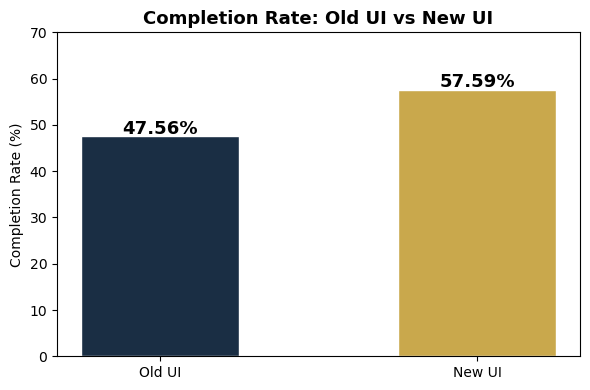

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Old UI', 'New UI']
values = [cr_control * 100, cr_test * 100]
bars = ax.bar(labels, values, color=['#1A2E44', '#C9A84C'], edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.5, f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_title('Completion Rate: Old UI vs New UI', fontsize=13, fontweight='bold')
ax.set_ylabel('Completion Rate (%)')
ax.set_ylim(0, 70)
plt.tight_layout()
plt.show()

---
## 4. Error Rate KPI

In [30]:
step_order = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}
# Join experiment group
df_web_exp = df_web.merge(exp, on='client_id', how='inner')
df_web_exp['step_num'] = df_web_exp['process_step'].map(step_order)
df_web_exp = df_web_exp.sort_values(['visit_id', 'date_time'])
# Previous step within each visit
df_web_exp['prev_step'] = df_web_exp.groupby('visit_id')['step_num'].shift(1)
df_web_exp['is_error']  = (df_web_exp['step_num'] < df_web_exp['prev_step']).astype(int)
# Drop first row of each visit (there is nothing to compare against)
df_steps = df_web_exp.dropna(subset=['prev_step'])
print(f'Total step transitions: {len(df_steps):,}')
print(f'Total backward steps:   {df_steps["is_error"].sum():,}')

Total step transitions: 248,030
Total backward steps:   26,040


In [31]:
er = df_steps.groupby('Variation')['is_error'].agg(['sum','count','mean'])
er.columns = ['backward_steps', 'total_steps', 'error_rate']
er['error_rate_%'] = (er['error_rate'] * 100).round(2)

In [32]:
er_test = er.loc['Test', 'error_rate']
er_control = er.loc['Control', 'error_rate']
display(er)
print(f'New UI: {er_test*100:.2f}%')
print(f'Old UI: {er_control*100:.2f}%')

,backward_steps,total_steps,error_rate,error_rate_%
Variation,,,,
Control,9700,108416,0.089470,8.95
Test,16340,139614,0.117037,11.70


New UI: 11.70%
Old UI: 8.95%


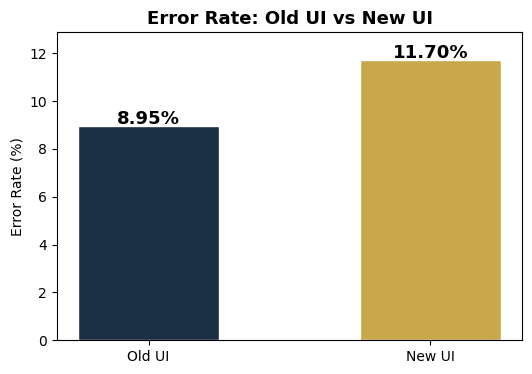

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Old UI', 'New UI']
values = [er_control * 100, er_test * 100]
bars = ax.bar(labels, values, color=['#1A2E44', '#C9A84C'], edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.1,f'{val:.2f}%',ha='center', fontsize=13, fontweight='bold')
ax.set_title('Error Rate: Old UI vs New UI', fontsize=13, fontweight='bold')
ax.set_ylabel('Error Rate (%)')
ax.set_ylim(0, max(values) * 1.1)
plt.show()

---
## 5. Hypothesis Test

- Do clients who make errors still complete the process more than those who never go backwards?

In [34]:
# Tag each visit as error-maker or not
visit_errors = (df_steps.groupby('visit_id')['is_error'].sum().reset_index())
visit_errors.columns = ['visit_id', 'total_errors']
visit_errors['made_error'] = (visit_errors['total_errors'] > 0).astype(int)
# Join back onto last_step
ls2 = last_step.merge(visit_errors, on='visit_id', how='inner')
print('Error makers: ', (ls2['made_error']==1).sum())
print('No errors: ', (ls2['made_error']==0).sum())

Error makers:  16581
No errors:  41039


In [35]:
# Completion rate: Error makers vs no errors
errors = ls2[ls2['made_error'] == 1]['completed']
no_errors  = ls2[ls2['made_error'] == 0]['completed']
p_err = errors.mean()
p_none = no_errors.mean()
se = np.sqrt(p_err*(1-p_err)/len(errors) + p_none*(1-p_none)/len(no_errors))
z = (p_err - p_none) / se
p_val = 2 * (1 - norm.cdf(abs(z)))
print(f'Made errors: {p_err*100:.2f}%')
print(f'No errors: {p_none*100:.2f}% ')
print(f'z-statistic: {z:.3f}')
print(f'p-value: {p_val:.4f}')
if p_val < 0.05:
    print('Significant difference found')
else:
    print('No significant difference found')

Made errors: 41.41%
No errors: 64.62% 
z-statistic: -51.623
p-value: 0.0000
Significant difference found


In [36]:
# Breaking it down by Old UI vs New UI
breakdown = (ls2.groupby(['Variation', 'made_error'])['completed'].mean().mul(100).round(2).unstack())
breakdown.columns = ['No errors', 'Made errors']
breakdown.index = ['Old UI', 'New UI']
print('Completion rate by group and error type:')
breakdown

Completion rate by group and error type:


,No errors,Made errors
Old UI,59.48,43.70
New UI,69.40,39.92


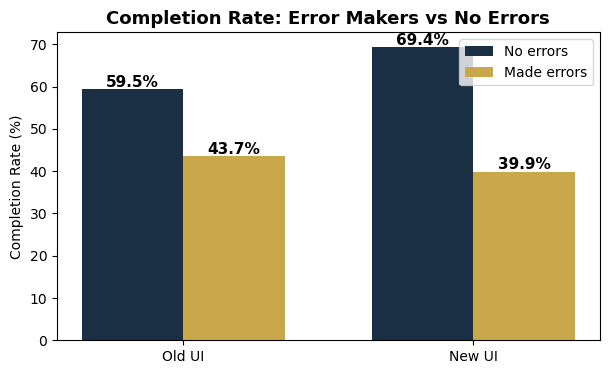

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, breakdown['No errors'],  width, label='No errors',   color='#1A2E44')
bars2 = ax.bar(x + width/2, breakdown['Made errors'], width, label='Made errors', color='#C9A84C')
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Old UI', 'New UI'])
ax.set_title('Completion Rate: Error Makers vs No Errors', fontsize=13, fontweight='bold')
ax.set_ylabel('Completion Rate (%)')
ax.legend()
plt.show()

- In the New UI, clients who never made an error completed at 69.4%.
- Even New UI error makers completed at 39.9%...Similar to Old UI error-makers at 43.7%.

---
## Save outputs for Phase 3 & shared use

In [38]:
last_step.to_csv('last_step.csv', index=False)
df_steps.to_csv('steps_with_errors.csv', index=False)

---
## Summary

### Completion Rate

- The new UI achieved a **57.59% completion rate**, compared to **47.56%** for the old UI.
- This represents a **+10.02 percentage point improvement** in completions.
- The result suggests the new UI significantly improved user completion behavior.

### Error Rate
- The new UI showed an **11.70% error rate**, slightly higher than the **8.95%** error rate in the old UI.
*-Despite the increase in errors, overall completion performance still improved under the new UI.

### Support Calls vs Completion

- Users who made errors completed at a substantially lower rate (**41.41%**) compared to users with no errors (**64.62%**).
- Statistical testing confirmed this difference was highly significant (**p < 0.001**).
- This indicates that high-friction users may require additional support or a separate engagement strategy.

### Business Recommendation

- Continue with the new UI rollout due to the strong improvement in completion rates.
- Investigate the higher error rate to reduce friction without sacrificing conversion gains.
- Develop targeted interventions for high-support or error-prone users.


---
## Bonus Hypotheses: To be completed in Visualisation Phase

Hypothesis A: Does time of day affect completion rate?
- Extract hour from date_time, compare morning vs evening completion rates

Hypothesis B: Do clients who spend longer on step 1 complete more?
- Split by time spent on step 1, compare completion rates